In [ ]:
from   google.colab   import   drive
drive.mount ( '/content/drive' )

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/skin_project/archive (2).zip"
extract_path = "/content/psoriasis_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("تم فك الضغط بنجاح")

تم فك الضغط بنجاح


In [ ]:
os.listdir("/content/psoriasis_dataset")

['NORMAL_SKIN', 'PSORIASIS']

In [ ]:
normal_path = "/content/psoriasis_dataset/NORMAL_SKIN"
psoriasis_path = "/content/psoriasis_dataset/PSORIASIS"

print("عدد صور الجلد الطبيعي:", len(os.listdir(normal_path)))
print("عدد صور الصدفية:", len(os.listdir(psoriasis_path)))

عدد صور الجلد الطبيعي: 4099
عدد صور الصدفية: 5908


معرفة مسار المجلد


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['162.txt', '62.txt', 'Untitled17 (1).ipynb', 'Untitled17.html', 'Untitled17.ipynb', 'NLP HOMEWORK - PART 5 BY [رقية عبد اللطيف] (2).html', 'NLP HOMEWORK - PART 5 BY [رقية عبد اللطيف] (2).ipynb', 'رقية عبد اللطيف', '20250206_125550.jpg', 'Colab Notebooks', 'Untitled spreadsheet.gsheet', 'RSVP.gform', 'Untitled presentation (1).gslides', 'مشروع امراض الجلد', 'Untitled presentation.gslides', 'Photo album.gslides', 'Presentation', 'Photo album.pptx', 'skin_project', 'skin_project222', 'كتاب مشروع تصنيف الصدفية V1.gdoc', 'inbound3959523900701900764.jpg', 'psoriasis_model.h5']


In [ ]:
print(os.listdir("/content/drive/MyDrive/skin_project"))

['archive (2).zip', 'history.pkl', 'models', 'psoriasis_model.h5', 'dataset']


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/skin_project/archive (2).zip"
extract_path = "/content/drive/MyDrive/skin_project/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done extracting ✔")

Done extracting ✔


تحميل الداتا

In [ ]:
import tensorflow as tf

data_path = "/content/drive/MyDrive/skin_project/dataset"

dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    image_size=(224,224),
    batch_size=32,
    label_mode="binary",
    shuffle=True,
    seed=123
)

Found 10007 files belonging to 2 classes.


تقسيم الداتا

In [ ]:
train_size = int(0.8 * len(dataset))

train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

تحسين الاداء

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

الموديل

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


التصنيف

In [ ]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

الكومبايل

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

التدريب

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 296s 1s/step - accuracy: 0.9252 - loss: 0.1921 - val_accuracy: 0.9711 - val_loss: 0.0971
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.9736 - loss: 0.0882 - val_accuracy: 0.9756 - val_loss: 0.0843
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 279s 1s/step - accuracy: 0.9793 - loss: 0.0737 - val_accuracy: 0.9766 - val_loss: 0.0757
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.9803 - loss: 0.0645 - val_accuracy: 0.9776 - val_loss: 0.0692
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step - accuracy: 0.9815 - loss: 0.0578 - val_accuracy: 0.9771 - val_loss: 0.0745
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 282s 1s/step - accuracy: 0.9825 - loss: 0.0558 - val_accuracy: 0.9786 - val_loss: 0.0689
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step - accuracy: 0.9844 - loss: 0.0537 - val_accuracy: 0.9806 - val_loss: 0.0583
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step - accuracy: 0.9833 - loss: 0.0520 - val_accu

فاين تيوننغ

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 407s 2s/step - accuracy: 0.9921 - loss: 0.0224 - val_accuracy: 0.9846 - val_loss: 0.0406
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.9951 - loss: 0.0144 - val_accuracy: 0.9856 - val_loss: 0.0387
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 396s 2s/step - accuracy: 0.9962 - loss: 0.0120 - val_accuracy: 0.9841 - val_loss: 0.0585
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 396s 2s/step - accuracy: 0.9958 - loss: 0.0127 - val_accuracy: 0.9875 - val_loss: 0.0340
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.9992 - loss: 0.0057 - val_accuracy: 0.9870 - val_loss: 0.0315


 حفظ الموديل

In [ ]:
model.save("/content/drive/MyDrive/psoriasis_model.h5")

ال accuracy

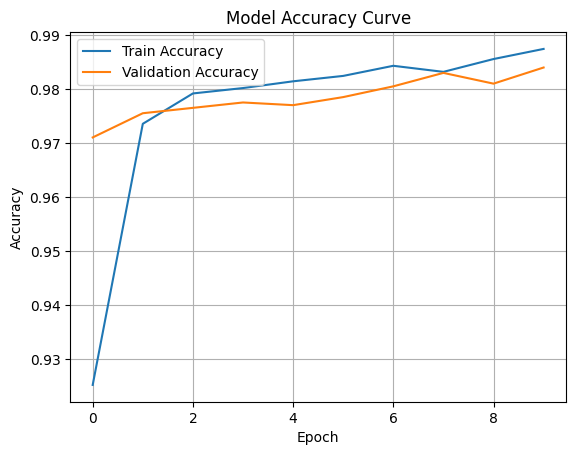

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [ ]:
print("Train Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])

print("Train Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])

Train Accuracy: 0.987500011920929
Validation Accuracy: 0.9840558171272278
Train Loss: 0.042602717876434326
Validation Loss: 0.05538923293352127


In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    # Accuracy
    plt.figure()
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend()
    plt.title('Accuracy')
    plt.show()

    # Loss
    plt.figure()
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend()
    plt.title('Loss')
    plt.show()

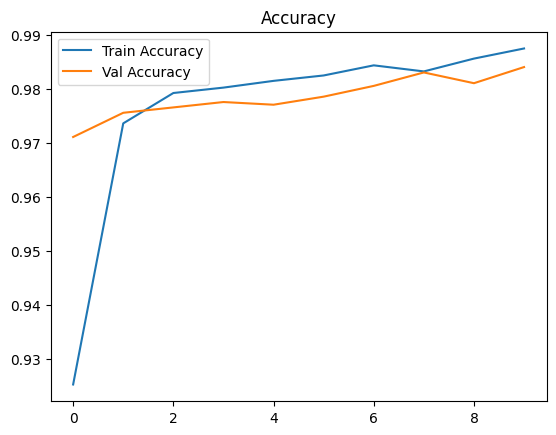

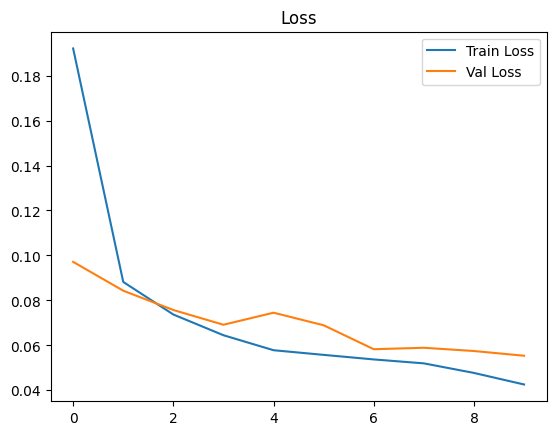

In [ ]:
plot_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 726ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 959ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 742ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 734ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 745ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 743ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 737ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 937ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 948ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 744ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 746ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 748ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 748ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 725ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 734ms/

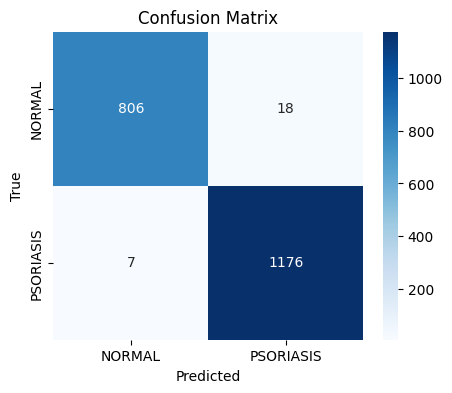

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# جمع التوقعات
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["NORMAL", "PSORIASIS"],
            yticklabels=["NORMAL", "PSORIASIS"])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

كود ال pdf

In [ ]:
!pip install gradio reportlab -q

import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image
from datetime import datetime
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

# تحميل الموديل
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/psoriasis_model.h5"
)

# دالة التحليل وإنشاء PDF
def predict_skin(name, age, gender, image):

    date = datetime.now().strftime("%Y-%m-%d")

    # تجهيز الصورة
    image = image.resize((224,224))
    image = np.array(image)

    if image.shape[-1] == 4:
        image = image[:, :, :3]

    image = image / 255.0
    image = np.expand_dims(image, axis=0)

    # التنبؤ
    prediction = model.predict(image)[0][0]

    if prediction >= 0.5:
        label = "PSORIASIS"
        status = "⚠️ Psoriasis Detected"
        confidence = prediction * 100
    else:
        label = "NORMAL SKIN"
        status = "✅ Healthy Skin"
        confidence = (1 - prediction) * 100

    # التقرير النصي
    report = f"""
SKIN AI REPORT

Patient Name : {name}
Age          : {age}
Gender       : {gender}
Date         : {date}

Prediction   : {label}
Confidence   : {confidence:.2f}%
Status       : {status}
"""

    # إنشاء PDF
    pdf_path = "skin_report.pdf"

    doc = SimpleDocTemplate(pdf_path)
    styles = getSampleStyleSheet()
    elements = []

    title = Paragraph("<b>SKIN AI MEDICAL REPORT</b>", styles['Title'])
    elements.append(title)
    elements.append(Spacer(1, 20))

    body = Paragraph(
        report.replace("\n", "<br/>"),
        styles['BodyText']
    )

    elements.append(body)

    doc.build(elements)

    return report, pdf_path

# تصميم الواجهة
with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🏥 Skin AI App
    ### AI-Based Psoriasis Detection System
    """)

    with gr.Row():

        with gr.Column():

            name = gr.Textbox(label="👤 Patient Name")

            age = gr.Number(label="🎂 Age")

            gender = gr.Radio(
                ["Male", "Female"],
                label="⚧ Gender"
            )

            image = gr.Image(
                type="pil",
                label="📷 Upload Skin Image"
            )

            analyze_btn = gr.Button(
                "🔍 Analyze",
                variant="primary"
            )

        with gr.Column():

            report_output = gr.Textbox(
                label="🩺 Medical Report",
                lines=15
            )

            pdf_output = gr.File(
                label="📄 Download PDF Report"
            )

    analyze_btn.click(
        fn=predict_skin,
        inputs=[name, age, gender, image],
        outputs=[report_output, pdf_output]
    )

demo.launch(share=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 63.0 MB/s eta 0:00:00


/tmp/ipykernel_5667/3876361093.py:80: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://156f5f1a2772ad6904.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
